In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from joblib import dump

In [2]:
df = pd.read_csv('data/car_predict_price.csv')

In [3]:
df

,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,...,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Max Power bhp,Max Power rpm,Max Torque Nm,Max Torque rpm,Make - Model
0,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,...,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0,109.0000,4500.0,Honda - Amaze 1.2 VX i-VTEC
1,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,...,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0,190.0000,2000.0,Maruti Suzuki - Swift DZire VDI
2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,...,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0,112.7619,4000.0,Hyundai - i10 Magna 1.2 Kappa2
3,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,...,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0,113.0000,4200.0,Toyota - Glanza G
4,1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,...,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0,343.0000,1400.0,Toyota - Innova 2.4 VX 7 STR [2016-2020]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,850000,2016,90300,Diesel,Manual,Surat,White,First,Individual,2179.0,...,4585.0,1890.0,1785.0,7.0,70.0,138.0,3750.0,330.0000,1600.0,Mahindra - XUV500 W8 [2015-2017]
2055,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,Individual,814.0,...,3495.0,1550.0,1500.0,5.0,32.0,55.0,5500.0,75.0000,4000.0,Hyundai - Eon D-Lite +
2056,240000,2013,73000,Petrol,Manual,Thane,Silver,First,Individual,1196.0,...,3795.0,1680.0,1427.0,5.0,45.0,70.0,6250.0,102.0000,4000.0,Ford - Figo Duratec Petrol ZXI 1.2
2057,4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,Individual,1995.0,...,4936.0,1868.0,1479.0,5.0,65.0,188.0,4000.0,400.0000,1750.0,BMW - 5-Series 520d Luxury Line [2017-2019]


---
## Preprocessing

In [4]:
X = df.drop('Price', axis=1)
y = df['Price']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [6]:
numeric_columns = X.select_dtypes(exclude='object').columns

In [7]:
numeric_columns

Index(['Year', 'Kilometer', 'Engine', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity', 'Max Power bhp',
       'Max Power rpm', 'Max Torque Nm', 'Max Torque rpm'],
      dtype='object')

In [8]:
categorical_columns = X.select_dtypes(include='object').columns

In [9]:
categorical_columns

Index(['Fuel Type', 'Transmission', 'Location', 'Color', 'Owner',
       'Seller Type', 'Drivetrain', 'Make - Model'],
      dtype='object')

**Preprocessing for linear models**

In [10]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) 

In [11]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [12]:
preprocessor = ColumnTransformer(transformers=[
    ('num_columns', numerical_pipeline, numeric_columns),
    ('cat_columns', categorical_pipeline, categorical_columns),
])

**Preprocessing for tree based model**

In [13]:
categorical_pipeline_tree_based_models = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) 

In [14]:
preprocessor_tree_based_models = ColumnTransformer(transformers=[
    ('num_columns', SimpleImputer(strategy='median'), numeric_columns),
    ('cat_columns', categorical_pipeline_tree_based_models, categorical_columns),
])

---
# Training Models
**This section first training models with default hyperparameters and evaluation models with MAE, RMSE and R2 and second We are training best model with GridSearchCV and find best hyperparameter**

---

## First section

In [25]:
base_models = {
    'linear_regression': LinearRegression(),
    'elasticnet': ElasticNet(random_state=101),
    'random_forest': RandomForestRegressor(random_state=101),
    'gradient_boosting': GradientBoostingRegressor(random_state=101),
    'AdaBoost': AdaBoostRegressor(random_state=101),
    'svm': SVR(),
}

In [26]:
mae_scores = dict()
rmse_scores = dict()
r2_scores = dict()

for name, model in base_models.items():
    if name in ['random_forest', 'gradient_boosting', 'AdaBoost']:
        steps = [
            ('preprocessor_tree', preprocessor_tree_based_models),
            (name, model)
        ]
    else:
        steps = [
        ('preprocessor', preprocessor),
        (name, model)
        ]
    
    pipe = Pipeline(steps=steps)
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    mae_scores[name] = mean_absolute_error(y_test, y_pred)
    rmse_scores[name] = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_scores[name] = r2_score(y_test, y_pred)

In [27]:
errors = pd.DataFrame(data=[mae_scores, rmse_scores, r2_scores]).transpose()

In [28]:
errors.columns = ['MAE', 'RMSE', 'R2']

In [29]:
errors

,MAE,RMSE,R2
linear_regression,9.154698e+05,2.161141e+06,0.209365
elasticnet,7.122732e+05,1.428766e+06,0.654433
random_forest,2.593199e+05,6.117678e+05,0.936645
gradient_boosting,2.988541e+05,5.446917e+05,0.949776
AdaBoost,1.385776e+06,1.499541e+06,0.619350
svm,1.225727e+06,2.573711e+06,-0.121319


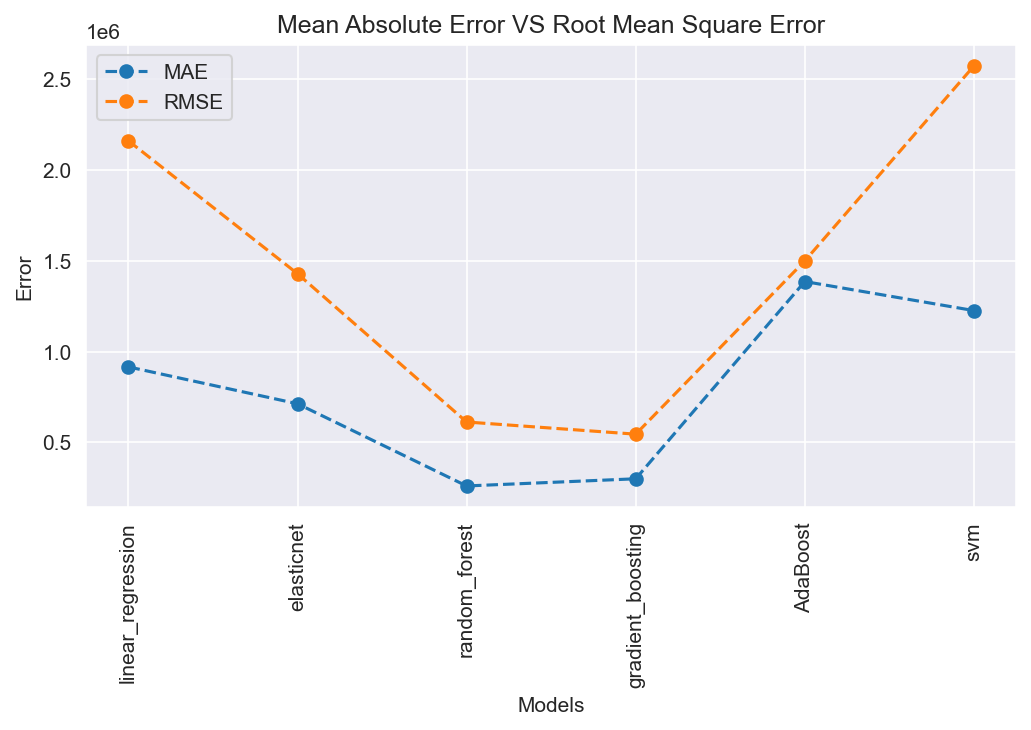

In [30]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(errors.index, errors['MAE'], 'o--', label='MAE')
plt.plot(errors.index, errors['RMSE'], 'o--', label='RMSE')
plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Mean Absolute Error VS Root Mean Square Error') 
plt.legend()
plt.xticks(rotation=90);

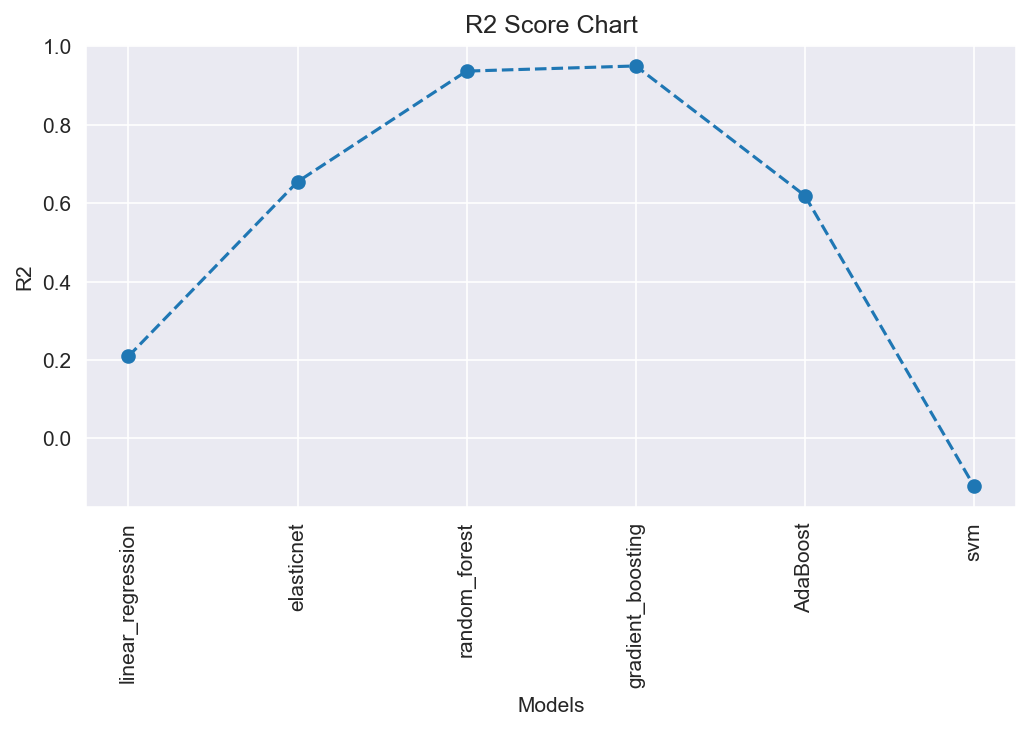

In [31]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(errors.index, errors['R2'], 'o--')
plt.xlabel('Models')
plt.ylabel('R2')
plt.title('R2 Score Chart')
plt.xticks(rotation=90);

---
## Second Section

In [16]:
tuned_models = {
    'random_forest': RandomForestRegressor(random_state=101),
    'gradient_boosting': GradientBoostingRegressor(random_state=101),
}

In [56]:
params_dict = {
    'gradient_boosting': {
        'gradient_boosting__n_estimators': [100, 200, 300, 400],
        'gradient_boosting__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
        'gradient_boosting__max_depth': [10, 25, 50, 100],
        'gradient_boosting__min_samples_split': [5, 10, 20, 50, 100],
        'gradient_boosting__criterion': ['friedman_mse', 'squared_error'],
        'gradient_boosting__max_features': ['sqrt', 'log2'],
    },
    'random_forest': {
        'random_forest__n_estimators': [100, 200, 300, 400],
        'random_forest__max_depth': [10, 25, 50, 100],
        'random_forest__min_samples_split': [5, 10, 20, 50, 100],
        'random_forest__criterion': ["squared_error", "absolute_error", "friedman_mse"],
        'random_forest__max_features': ['sqrt', 'log2', None],  
    }
    
}

In [57]:
mae_tuned = dict()
rmse_tuned = dict()
r2_tuned = dict()

trained_models = dict()

for name, model in tuned_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_tree_based_models),
        (name, model)
    ])
    
    randomized_search = RandomizedSearchCV(
        pipe,
        params_dict.get(name),
        n_iter=50,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=101)
    
    randomized_search.fit(X_train, y_train)
    predict = randomized_search.predict(X_test)
    
    mae_tuned[name] = mean_absolute_error(y_test, predict)
    rmse_tuned[name] = np.sqrt(mean_squared_error(y_test, predict))
    r2_tuned[name] = r2_score(y_test, predict)
    
    model_info = {
        'estimator': randomized_search.best_estimator_,
        'predict_value': predict,
        'params': randomized_search.best_params_,
    }
    
    trained_models[name] = model_info


KeyboardInterrupt



In [19]:
errors_tuned = pd.DataFrame(data=[mae_tuned, rmse_tuned, r2_tuned]).transpose()

In [20]:
errors_tuned.columns = ['MAE Tuned', 'RMSE Tuned', 'R2 Tuned']

In [21]:
errors_tuned

,MAE Tuned,RMSE Tuned,R2 Tuned
random_forest,426405.033193,852041.529224,0.877106
gradient_boosting,313054.706796,605289.004467,0.937980


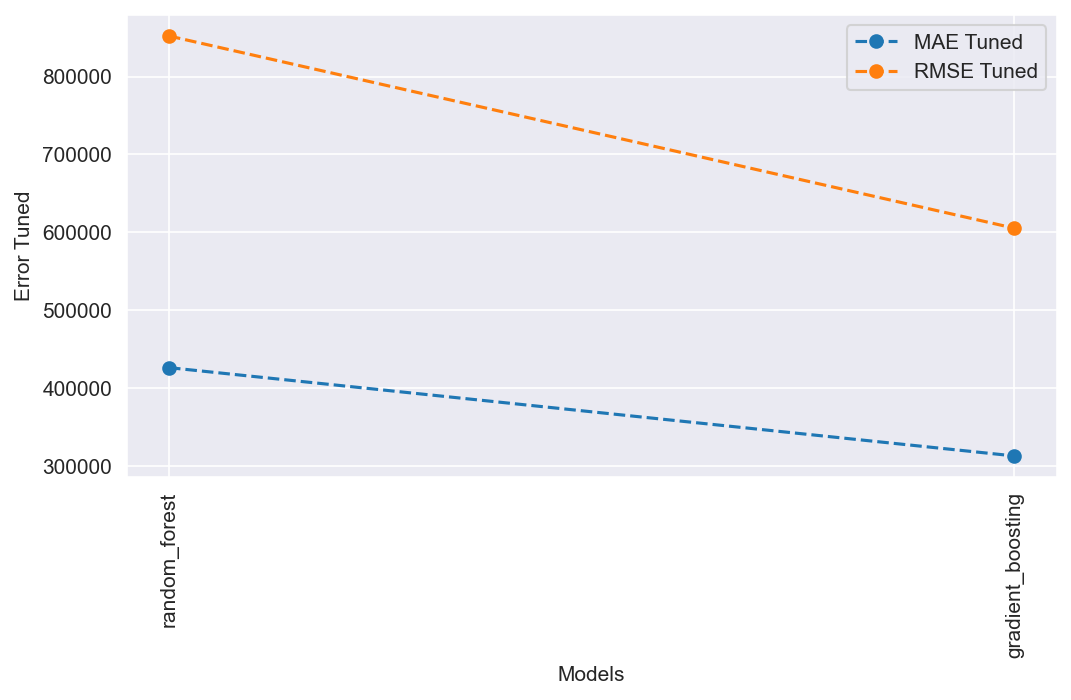

In [22]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(errors_tuned.index, errors_tuned['MAE Tuned'], 'o--', label='MAE Tuned')
plt.plot(errors_tuned.index, errors_tuned['RMSE Tuned'], 'o--', label='RMSE Tuned')
plt.xlabel('Models')
plt.ylabel('Error Tuned')
plt.legend()
plt.xticks(rotation=90);

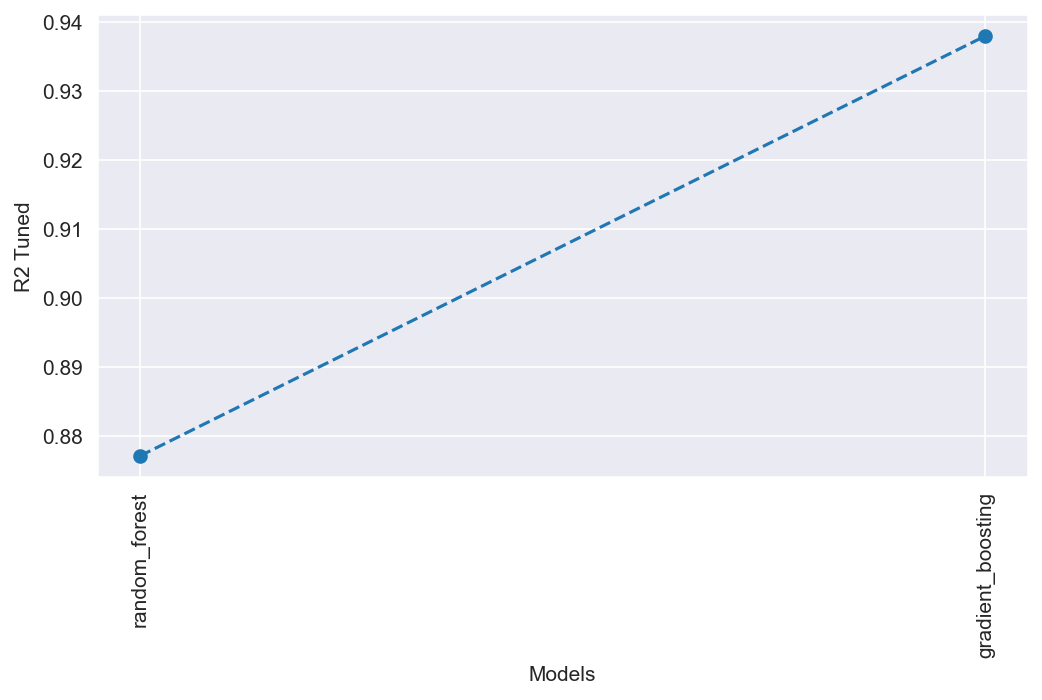

In [23]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(errors_tuned.index, errors_tuned['R2 Tuned'], 'o--')
plt.xlabel('Models')
plt.ylabel('R2 Tuned')
plt.xticks(rotation=90);

In [32]:
pd.concat([errors, errors_tuned], axis=1, join='inner')

,MAE,RMSE,R2,MAE Tuned,RMSE Tuned,R2 Tuned
random_forest,259319.879782,611767.770153,0.936645,426405.033193,852041.529224,0.877106
gradient_boosting,298854.132173,544691.682626,0.949776,313054.706796,605289.004467,0.937980


In [33]:
best_model = trained_models.get('gradient_boosting').get('estimator')

In [34]:
feature_importances = best_model.named_steps['gradient_boosting'].feature_importances_

In [35]:
feature_importances

array([2.24403191e-02, 3.06425280e-02, 1.37235596e-01, ...,
       6.94614746e-05, 5.03545563e-05, 1.16194750e-03], shape=(1053,))

In [36]:
feature_name = best_model.named_steps['preprocessor'].get_feature_names_out()

In [37]:
feature_name

array(['num_columns__Year', 'num_columns__Kilometer',
       'num_columns__Engine', ...,
       'cat_columns__Make - Model_Volvo - XC60 Inscription',
       'cat_columns__Make - Model_Volvo - XC60 Inscription [2017-2020]',
       'cat_columns__Make - Model_Volvo - XC90 D5 Inscription'],
      shape=(1053,), dtype=object)

In [38]:
clean_feature_name = np.vectorize(lambda x: x.split('__')[1])(feature_name)

In [39]:
clean_feature_name

array(['Year', 'Kilometer', 'Engine', ...,
       'Make - Model_Volvo - XC60 Inscription',
       'Make - Model_Volvo - XC60 Inscription [2017-2020]',
       'Make - Model_Volvo - XC90 D5 Inscription'],
      shape=(1053,), dtype='<U73')

In [40]:
feature_importances_df = pd.DataFrame(
    data={
        'feature': clean_feature_name,
        'importance': feature_importances
    }
).sort_values('importance', ascending=False)

In [41]:
feature_importances_df

,feature,importance
3,Length,0.140080
2,Engine,0.137236
4,Width,0.126101
8,Max Power bhp,0.096319
7,Fuel Tank Capacity,0.066164
...,...,...
1016,Make - Model_Volkswagen - Polo 1.2 TDI,0.000000
1017,Make - Model_Volkswagen - Polo 1.5 TDI,0.000000
1018,Make - Model_Volkswagen - Polo Comfortline 1.2...,0.000000
1019,Make - Model_Volkswagen - Polo Comfortline 1.2...,0.000000


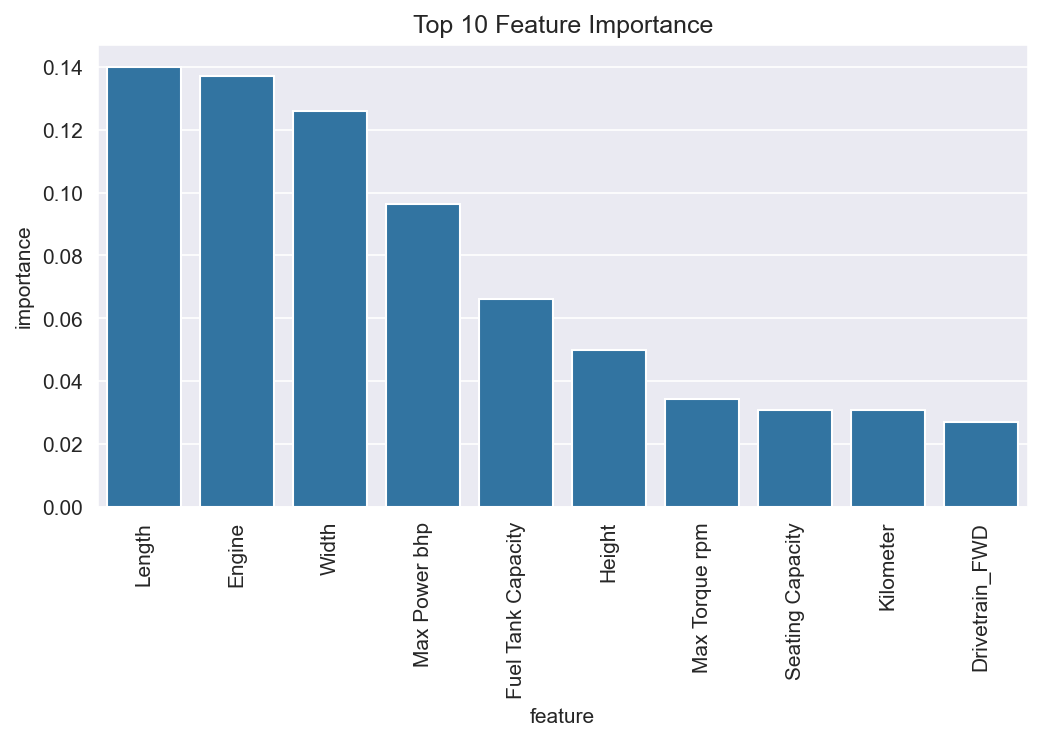

In [42]:
plt.figure(figsize=(8,4), dpi=150)
sns.barplot(x='feature', y='importance', data=feature_importances_df[:10])
plt.title('Top 10 Feature Importance')
plt.xticks(rotation=90);

In [43]:
pred = trained_models.get('gradient_boosting').get('predict_value')

In [44]:
residual = y_test - pred

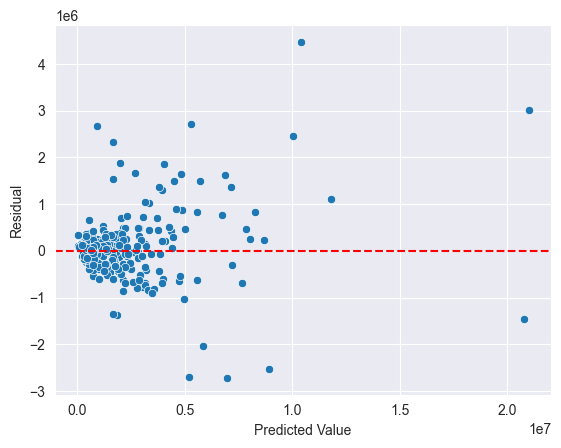

In [45]:
sns.scatterplot(x=pred, y=residual)
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.axhline(0, color='red', linestyle='--')

Text(0, 0.5, 'Predicted Price')

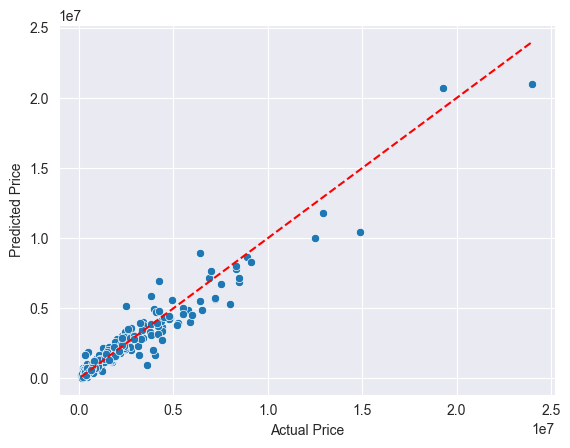

In [46]:
sns.scatterplot(x=y_test, y=pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

In [47]:
trained_models.get('gradient_boosting').get('params')

{'gradient_boosting__n_estimators': 250,
 'gradient_boosting__min_samples_split': 7,
 'gradient_boosting__max_features': 'sqrt',
 'gradient_boosting__max_depth': 5,
 'gradient_boosting__learning_rate': 0.15,
 'gradient_boosting__criterion': 'squared_error'}

---
## Final model training

In [48]:
final_model = best_model

In [49]:
final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_columns',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Year', 'Kilometer', 'Engine', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity', 'Max Power bhp',
       'Max Power rpm', 'Max Torque Nm', 'Max Torque rpm'],
      dtype='object')),
                                                 ('cat_columns',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy=...
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Fuel Type', 'Transmission', 'Location', 'Color', 'Owner',
       'Seller Type', 'Drivetrain', 'Make - Model'],
      dtype='object'))])),
                ('gradient_boosting',
                 GradientBoostingRegressor(criterion='squared_error',
                                           learning_rate=0.15, max_depth=5,
                                           max_features='sqrt',
                                           min_samples_split=7,
                                           n_estimators=250,
                                           random_state=101))])

In [50]:
dump(final_model, 'model/final_model.pkl')

['model/final_model.pkl']